In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

print(X)
print(y)

[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
[[0.]
 [1.]
 [1.]
 [0.]]


In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
print(sigmoid(0))

0.5


In [ ]:
def sigmoid_derivative(output):
    return output * (1 - output)
print(sigmoid_derivative(0.5))

0.25


In [ ]:
np.random.seed(42)

input_size = 2
hidden_size = 4
output_size = 1

In [ ]:
W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

print(W1.shape)
print(b1.shape)
print(W2.shape)
print(b2.shape)

(2, 4)
(1, 4)
(4, 1)
(1, 1)


In [ ]:
learning_rate = 0.1
epochs = 10000

loss_history = []

In [ ]:
z1 = np.dot(X, W1) + b1
a1 = sigmoid(z1)

z2 = np.dot(a1, W2) + b2
predictions = sigmoid(z2)

print(predictions)

[[0.44669943]
 [0.43029337]
 [0.42699871]
 [0.41263144]]


In [ ]:
loss = np.mean((y - predictions) ** 2)

print(loss)

0.2556753002334093


In [ ]:
output_error = predictions - y

output_delta = output_error * sigmoid_derivative(predictions)

In [ ]:
hidden_error = np.dot(output_delta, W2.T)

hidden_delta = hidden_error * sigmoid_derivative(a1)

In [ ]:
dW2 = np.dot(a1.T, output_delta)
db2 = np.sum(output_delta, axis=0, keepdims=True)

dW1 = np.dot(X.T, hidden_delta)
db1 = np.sum(hidden_delta, axis=0, keepdims=True)

In [ ]:
W2 -= learning_rate * dW2
b2 -= learning_rate * db2

W1 -= learning_rate * dW1
b1 -= learning_rate * db1

In [ ]:
for epoch in range(epochs):

    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    predictions = sigmoid(z2)

    loss = np.mean((y - predictions) ** 2)
    loss_history.append(loss)

    output_error = predictions - y
    output_delta = output_error * sigmoid_derivative(predictions)

    hidden_error = np.dot(output_delta, W2.T)
    hidden_delta = hidden_error * sigmoid_derivative(a1)

    dW2 = np.dot(a1.T, output_delta)
    db2 = np.sum(output_delta, axis=0, keepdims=True)

    dW1 = np.dot(X.T, hidden_delta)
    db1 = np.sum(hidden_delta, axis=0, keepdims=True)

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss = {loss:.6f}")

Epoch 0, Loss = 0.255101
Epoch 500, Loss = 0.250144


Epoch 1000, Loss = 0.250022
Epoch 1500, Loss = 0.249932
Epoch 2000, Loss = 0.249830
Epoch 2500, Loss = 0.249658
Epoch 3000, Loss = 0.249265
Epoch 3500, Loss = 0.248071
Epoch 4000, Loss = 0.243807
Epoch 4500, Loss = 0.230504
Epoch 5000, Loss = 0.202497
Epoch 5500, Loss = 0.167725
Epoch 6000, Loss = 0.124606
Epoch 6500, Loss = 0.075401
Epoch 7000, Loss = 0.039916
Epoch 7500, Loss = 0.022632
Epoch 8000, Loss = 0.014594
Epoch 8500, Loss = 0.010378
Epoch 9000, Loss = 0.007893
Epoch 9500, Loss = 0.006293


In [ ]:
z1 = np.dot(X, W1) + b1
a1 = sigmoid(z1)

z2 = np.dot(a1, W2) + b2
predictions = sigmoid(z2)

print(predictions)

[[0.07633868]
 [0.93109927]
 [0.93087826]
 [0.07357339]]


In [ ]:
binary_predictions = (predictions >= 0.5).astype(int)

print(binary_predictions)



[[0]
 [1]
 [1]
 [0]]


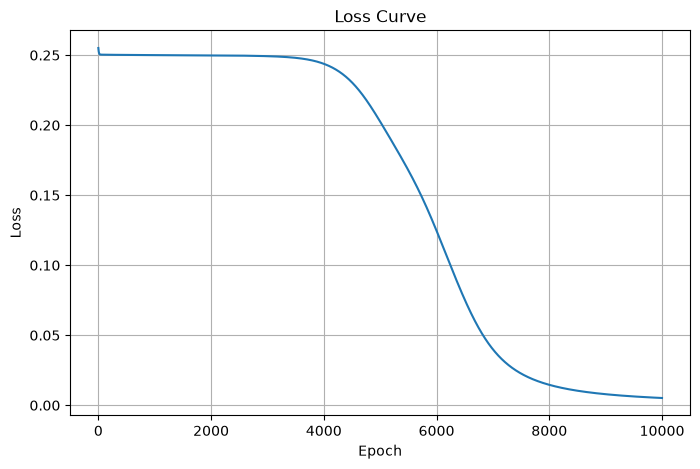

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.savefig("loss_curve.png")
plt.show()